# Homework 2

## Follow These Steps Before Submitting
Once you are finished, ensure to complete the following steps.

1.  Restart your kernel by clicking 'Kernel' > 'Restart & Run All'.

2.  Fix any errors which result from this.

3.  Repeat steps 1. and 2. until your notebook runs without errors.

4.  Submit your completed notebook to OWL by the deadline.


# 1. Fridge Light Failure

Imagine that you work for a company that sells fridges, with a lifetime warranty for the fridge lights. Your boss is interested in understanding the distribution of the number of lights that will fail in a given month, based on data collected over the last several years. The data were collected by hand and manually entered, so data entry errors are possible. There are also some months with missing data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

from scipy.stats import zscore
from scipy.special import factorial
import scipy.optimize as so

In [2]:
# Uncomment the line below if you are using Google colab
!gdown https://drive.google.com/uc?id=1wzY4XdkcwdNdVGL42PEN0ORtzWcdj2VF

Downloading...
From: https://drive.google.com/uc?id=1wzY4XdkcwdNdVGL42PEN0ORtzWcdj2VF
To: /content/Fridge Light Data.csv
100% 746/746 [00:00<00:00, 2.02MB/s]


1. Read the CSV file using Pandas and store it. All you've been given are a meaningless ID and the counts of the number of fridge lights that failed in each month.

In [3]:
df = pd.read_csv('Fridge Light Data.csv')
display(df.head())

,ID,x
0,1,24.0
1,2,33.0
2,3,31.0
3,4,NaN
4,5,31.0


2. Count the number of null values in the dataset, then remove them.

In [4]:
df.describe()

,ID,x
count,107.000000,103.000000
mean,54.000000,29.873786
std,31.032241,9.115468
min,1.000000,-2.000000
25%,27.500000,26.000000
50%,54.000000,29.000000
75%,80.500000,34.000000
max,107.000000,63.000000


In [5]:
df.isnull().any()

,0
ID,False
x,True


In [6]:
null_columns=df.columns[df.isnull().any()]
df.loc[:,null_columns].isnull().sum()

,0
x,4


Theres negatives as well as null, Theres four null values.

Number of null values: 4

In [7]:
df.dropna(axis=0, how='any', subset=None, inplace=True)
df.isnull().any()

,0
ID,False
x,False


In [8]:
df.describe()

,ID,x
count,103.000000,103.000000
mean,54.883495,29.873786
std,30.946919,9.115468
min,1.000000,-2.000000
25%,28.500000,26.000000
50%,55.000000,29.000000
75%,81.500000,34.000000
max,107.000000,63.000000


None anymore, but theres still negatives

3. Plot the distribution of the data. Add a title and axes labels to your plot.

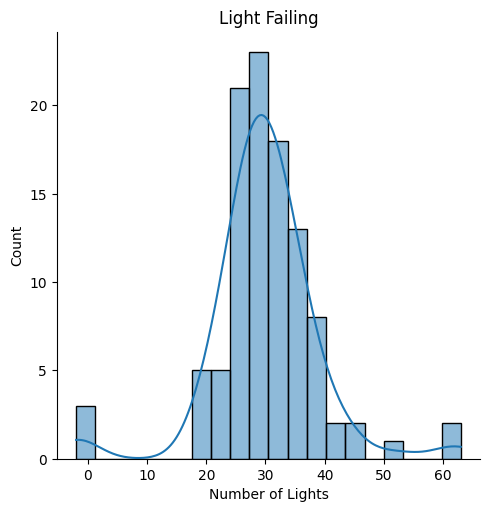

In [10]:
fig=sns.displot(data=df, x="x", kde='True')
plt.xlabel('Number of Lights')
plt.ylabel('Count')
plt.title('Light Failing')
plt.show()

4. Count the number of observations that you know with **certainty** are data entry errors, then remove them. Explain why you know they are errors.

In [11]:
lowest_10 = df.sort_values(by='x', ascending=True).head(10)
highest_10 = df.sort_values(by='x', ascending=False).head(10)
print("Lowest 10 rows:\n", lowest_10)
print("Highest 10 rows:\n", highest_10)

Lowest 10 rows:
     ID     x
77  78  -2.0
22  23  -2.0
91  92  -1.0
80  81  19.0
20  21  19.0
46  47  20.0
42  43  20.0
69  70  20.0
75  76  21.0
79  80  22.0
Highest 10 rows:
       ID     x
18    19  63.0
27    28  61.0
60    61  52.0
29    30  44.0
66    67  44.0
104  105  43.0
49    50  41.0
32    33  40.0
55    56  39.0
33    34  39.0


The three negative numbers are 100% errors. I would also ask about the numbers over 30, is their multiple lights in the fridge. If one then I would say with certanity then theres more errors, but right now with certainity will only remove the negatives. Especially the mean is 30.

In [12]:
df = df.loc[df['x'] >0]
df.describe()

,ID,x
count,100.000000,100.000000
mean,54.600000,30.820000
std,30.936559,7.386009
min,1.000000,19.000000
25%,28.750000,26.750000
50%,54.500000,29.500000
75%,81.250000,34.000000
max,107.000000,63.000000


Number of certain data entry errors: 3

5. Compute the negative log-likelihood based on the assumption that the data comes from a Poisson($\lambda$) distribution. The negative log-likelihood for a Poisson($\lambda$) distribution is as follows:

$$
nll(\lambda) = n \lambda - \left(\sum_{i=1}^{n}x_i\right) log(\lambda) + \sum_{i=1}^{n}log(x_i!)
$$

In [17]:
#test your function on a dummy dataset with lambda = 25
dummy_data = pd.DataFrame({'x': [20, 22, 18, 6, 8]})
def poissonNegLogLikelihood(t, data2):
  n=len(data2)
  sumx=np.sum(data2)
  lt=np.log(t)
  xf=np.log(factorial(data2))
  sumxf=np.sum(xf)
  nll=(n*t)-(sumx*lt)+(sumxf)
  return(nll)
nll_result = poissonNegLogLikelihood(25, dummy_data.x)
print('Negative Log-Likelhood:', nll_result)


Negative Log-Likelhood: 31.189286095130285


In [18]:
nll_result2 = poissonNegLogLikelihood(25, df.x)
print('Negative Log-Likelhood:', nll_result)

Negative Log-Likelhood: 31.189286095130285


6. Consider integer values of $\lambda$ ranging from 10 to 50. Compute the negative log-likelihood for each of these values and plot it. Include a title and axes labels on your plot. Based on the plot, what value of $\lambda$ is most likely to have generated the data? You may give a small range.

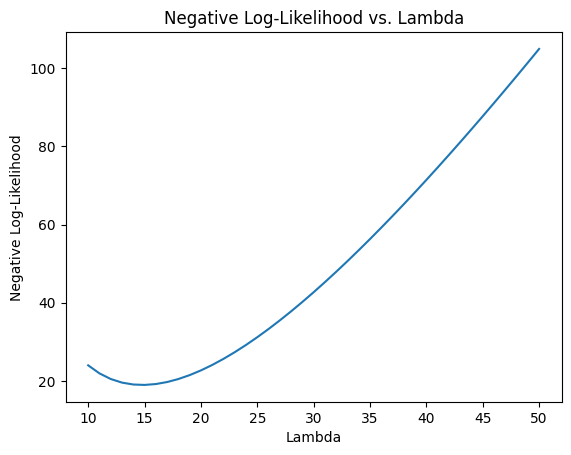

In [24]:
lambda_values = range(10, 51)
nll_values = [poissonNegLogLikelihood(x, dummy_data.x) for x in lambda_values]
plt.plot(lambda_values, nll_values)
plt.title('Negative Log-Likelihood vs. Lambda')
plt.xlabel('Lambda')
plt.ylabel('Negative Log-Likelihood')
plt.show()

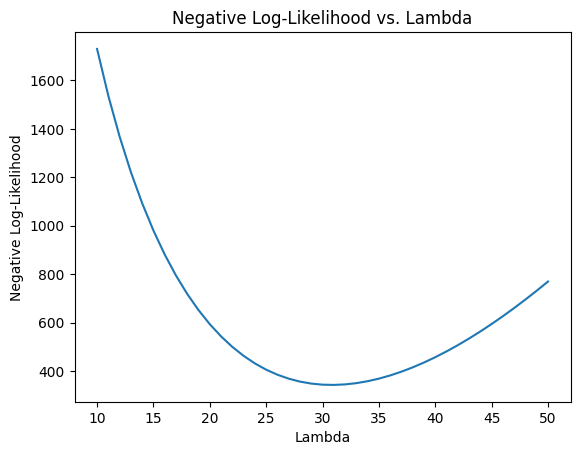

In [25]:
lambda_values = range(10, 51)
nll_values = [poissonNegLogLikelihood(x, df.x) for x in lambda_values]
plt.plot(lambda_values, nll_values)
plt.title('Negative Log-Likelihood vs. Lambda')
plt.xlabel('Lambda')
plt.ylabel('Negative Log-Likelihood')
plt.show()

Value of $\lambda$ most likely to have generated the data: 12-15 if dummy data

Value of $\lambda$ most likely to have generated the data: 28-30 if fridge

---



7. Compute the negative log-likelihood based on the assumption that the data comes from a Normal($\mu$, $\sigma$) distribution. The negative log-likelihood for a Normal($\mu$, $\sigma$) distribution is as follows:

$$
nll(\mu, \sigma) = \frac{n}{2}log(2π) + \frac{n}{2}log(\sigma^2) + \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

In [26]:
#test your function on a dummy dataset with mu = 25, sigma = 3
dummy_data = pd.DataFrame({'x': [20, 22, 18, 6, 8]})
def normalNegLogLikelihood(parmas, data):
  u, sd=parmas
  dummy_data_x=data
  n=(len(dummy_data_x))/2
  a=n*np.log(np.pi*2)
  b=n*np.log(sd**2)
  c=(1/(2*sd**2))*np.sum((dummy_data_x-u)**2)
  nll=a+b+c
  return(nll)

nll_result = normalNegLogLikelihood([25,3], dummy_data.x)
print('Negative Log-Likelhood:', round(nll_result,3))

Negative Log-Likelhood: 50.81


In [27]:
mean_value = df['x'].mean()
std_value = df['x'].std()
nll_result2 = normalNegLogLikelihood([mean_value,std_value], df.x)
print('Negative Log-Likelhood:', round(nll_result2,3))

Negative Log-Likelhood: 341.353


8. Determine the exact value of $\lambda$ that minimizes the negative log-likelihood for the Poisson distribution. Use so.minimize with method="Powell" and without a Jacobian.

In [30]:
result=so.minimize(poissonNegLogLikelihood, 15, args=(df.x), method="Powell")
print("Lambda:",round(result.x[0],2))

Lambda: 30.82


Value of $\lambda$ that minimizes the negative log-likelihood: 14.8

*9*. Determine the set of values of $\mu$ and $\sigma$ that minimizes the negative log-likelihood for the Normal distribution.

In [31]:
result2=so.minimize(normalNegLogLikelihood,x0=[15,15],args=(df['x'].values,),method="Powell")
print("Mu:",round(result2.x[0],2))
print("Sigma:",round(result2.x[1],2))

Mu: 30.82
Sigma: 7.35


Values for $\mu$ and $\sigma$ that minimize the negative log-likelihood: 30.82, 7.35


10. There are three data entry errors that could potentially be valid entries. Which three are most likely to be data entry errors? Identify them by their value (i.e., not their index in the data).

In [32]:
print("Highest 10 rows:\n", highest_10)

Highest 10 rows:
       ID     x
18    19  63.0
27    28  61.0
60    61  52.0
29    30  44.0
66    67  44.0
104  105  43.0
49    50  41.0
32    33  40.0
55    56  39.0
33    34  39.0


Three most likely data entry errors: 63,61 and 52

11. Remove the three observations that you think are most likely to be data entry errors. Determine the parameters that minimize the negative log-likelihoods for the Poisson($\lambda$) and Normal($\mu$, $\sigma$) distributions. Do your results change in a meaningful way?

In [33]:
df = df.loc[df['x'] <51]
df.describe()

,ID,x
count,97.000000,97.000000
mean,55.175258,29.958763
std,31.074846,5.528181
min,1.000000,19.000000
25%,30.000000,26.000000
50%,55.000000,29.000000
75%,82.000000,34.000000
max,107.000000,44.000000


In [34]:
result3=so.minimize(normalNegLogLikelihood,x0=[15,15],args=(df['x'].values,),method="Powell")
print("Mu:",round(result3.x[0],2))
print("Sigma:",round(result3.x[1],2))

Mu: 29.96
Sigma: 5.5


The variance reduced from 7.35 to 5.5 which is a significant reduction. The mean did not reduce much.

12. Between the Poisson and Normal models, which one do you think is best to use to represent the data? Why? Provide your answer in no more than two lines.

Normal model and distribution is better for continous data. While the possion model distribution is used for count data which is the case here.